In [1]:
# ============================================================
# BƯỚC 1: LOAD DATA & EDA (Exploratory Data Analysis)
# ==========================================================
# 1. Import các thư viện cần thiết
import pandas as pd  # pandas: thư viện xử lý dữ liệu dạng bảng
import numpy as np   # numpy: thư viện tính toán số học
import matplotlib.pyplot as plt  # matplotlib: vẽ biểu đồ
import seaborn as sns  # seaborn: vẽ biểu đồ đẹp hơn matplotlib

import os
print("Thư mục hiện tại:", os.getcwd())
print("Các file trong thư mục:", os.listdir())
# Cấu hình hiển thị cho đồ thị tiếng Việt
plt.rcParams['font.family'] = 'DejaVu Sans'  # Font hỗ trợ Unicode

# 2. Đọc file dữ liệu heart.csv
#    - pd.read_csv() đọc file CSV và trả về DataFrame (bảng dữ liệu)
#    - data/ là thư mục chứa dữ liệu
df = pd.read_csv('../data/heart.csv')

# 3. Xem 5 dòng đầu tiên để kiểm tra dữ liệu
#    - head() mặc định hiển thị 5 dòng đầu
#    - Mục đích: Kiểm tra xem dữ liệu đã load đúng chưa
print("=== 5 DÒNG ĐẦU TIÊN CỦA DỮ LIỆU ===")
print(df.head())

Thư mục hiện tại: f:\machine_learning\heart-prediction-nhom6\Heart-Disease-Prediction-ML-Group-6\notebooks
Các file trong thư mục: ['01_EDA.ipynb', '02_Preprocessing.ipynb', '03_Visualization.ipynb']
=== 5 DÒNG ĐẦU TIÊN CỦA DỮ LIỆU ===
   Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  MaxHR  \
0   40   M           ATA        140          289          0     Normal    172   
1   49   F           NAP        160          180          0     Normal    156   
2   37   M           ATA        130          283          0         ST     98   
3   48   F           ASY        138          214          0     Normal    108   
4   54   M           NAP        150          195          0     Normal    122   

  ExerciseAngina  Oldpeak ST_Slope  HeartDisease  
0              N      0.0       Up             0  
1              N      1.0     Flat             1  
2              N      0.0       Up             0  
3              Y      1.5     Flat             1  
4              N      

In [2]:
# GIẢI THÍCH TỪNG FEATURE TRONG DATASET
feature_explanations = {
    'Age': 'Tuổi của bệnh nhân (năm)',
    'Sex': 'Giới tính (M: Nam, F: Nữ)',
    'ChestPainType': 'Loại đau ngực (ATA, NAP, ASY, TA)',
    'RestingBP': 'Huyết áp lúc nghỉ (mmHg)',
    'Cholesterol': 'Cholesterol huyết thanh (mg/dL)',
    'FastingBS': 'Đường huyết lúc đói (0: <120, 1: >120 mg/dL)',
    'RestingECG': 'Kết quả điện tâm đồ lúc nghỉ (Normal, ST, LVH)',
    'MaxHR': 'Nhịp tim tối đa đạt được',
    'ExerciseAngina': 'Đau ngực do gắng sức (Y: Có, N: Không)',
    'Oldpeak': 'ST depression (chỉ số thiếu máu cơ tim)',
    'ST_Slope': 'Độ dốc đoạn ST (Up, Flat, Down)',
    'HeartDisease': 'MỤC TIÊU: 0=Không bệnh, 1=Có bệnh tim'
}

print("=== GIẢI THÍCH TỪNG FEATURE ===")
for col, desc in feature_explanations.items():
    print(f"{col:20s}: {desc}")

=== GIẢI THÍCH TỪNG FEATURE ===
Age                 : Tuổi của bệnh nhân (năm)
Sex                 : Giới tính (M: Nam, F: Nữ)
ChestPainType       : Loại đau ngực (ATA, NAP, ASY, TA)
RestingBP           : Huyết áp lúc nghỉ (mmHg)
Cholesterol         : Cholesterol huyết thanh (mg/dL)
FastingBS           : Đường huyết lúc đói (0: <120, 1: >120 mg/dL)
RestingECG          : Kết quả điện tâm đồ lúc nghỉ (Normal, ST, LVH)
MaxHR               : Nhịp tim tối đa đạt được
ExerciseAngina      : Đau ngực do gắng sức (Y: Có, N: Không)
Oldpeak             : ST depression (chỉ số thiếu máu cơ tim)
ST_Slope            : Độ dốc đoạn ST (Up, Flat, Down)
HeartDisease        : MỤC TIÊU: 0=Không bệnh, 1=Có bệnh tim


In [3]:
print("=== TUỔI TRUNG BÌNH THEO NHÓM BỆNH ===")
print(df.groupby('HeartDisease')['Age'].describe())


=== TUỔI TRUNG BÌNH THEO NHÓM BỆNH ===
              count       mean       std   min   25%   50%   75%   max
HeartDisease                                                          
0             410.0  50.551220  9.444915  28.0  43.0  51.0  57.0  76.0
1             508.0  55.899606  8.727056  31.0  51.0  57.0  62.0  77.0


In [4]:
print("=== TỶ LỆ BỆNH TIM THEO GIỚI TÍNH ===")
print(pd.crosstab(df['Sex'], df['HeartDisease'], margins=True))


=== TỶ LỆ BỆNH TIM THEO GIỚI TÍNH ===
HeartDisease    0    1  All
Sex                        
F             143   50  193
M             267  458  725
All           410  508  918


In [5]:
print("=== TỶ LỆ BỆNH THEO CHESTPAINTYPE ===")
ct = pd.crosstab(df['ChestPainType'], df['HeartDisease'])
ct['Tỷ lệ bệnh (%)'] = (ct[1] / (ct[0] + ct[1]) * 100).round(2)
print(ct)


=== TỶ LỆ BỆNH THEO CHESTPAINTYPE ===
HeartDisease     0    1  Tỷ lệ bệnh (%)
ChestPainType                          
ASY            104  392           79.03
ATA            149   24           13.87
NAP            131   72           35.47
TA              26   20           43.48


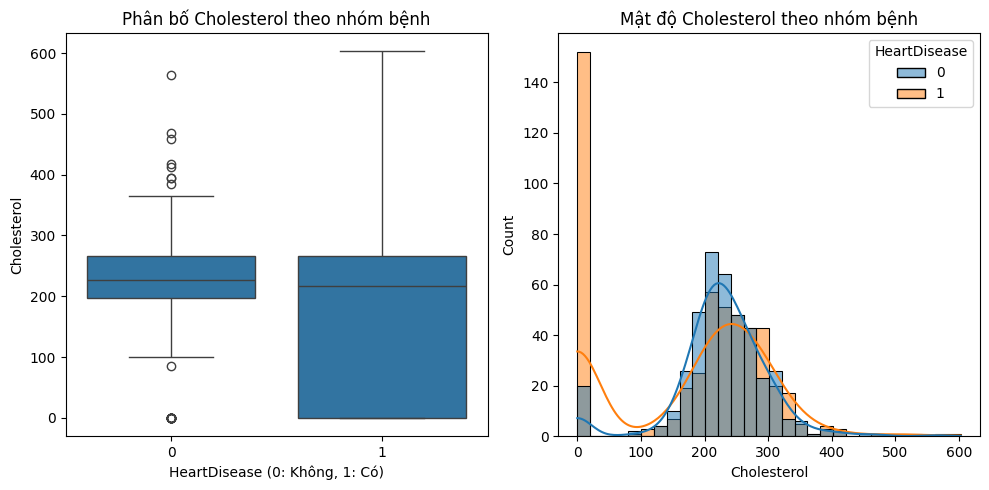

In [6]:
# Vẽ biểu đồ phân bố Cholesterol theo nhóm bệnh
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
sns.boxplot(data=df, x='HeartDisease', y='Cholesterol')
plt.title('Phân bố Cholesterol theo nhóm bệnh')
plt.xlabel('HeartDisease (0: Không, 1: Có)')

plt.subplot(1, 2, 2)
sns.histplot(data=df, x='Cholesterol', hue='HeartDisease', kde=True, bins=30)
plt.title('Mật độ Cholesterol theo nhóm bệnh')

plt.tight_layout()
plt.show()


In [7]:
# PHÁT HIỆN GIÁ TRỊ 0 VÔ LÝ
print("=== KIỂM TRA GIÁ TRỊ 0 VÔ LÝ ===")

# Các cột cần kiểm tra
columns_to_check = ['RestingBP', 'Cholesterol']

for col in columns_to_check:
    zero_count = (df[col] == 0).sum()
    if zero_count > 0:
        print(f"⚠️  {col}: CÓ {zero_count} giá trị bằng 0 ({zero_count/len(df)*100:.1f}%)")
        print(f"   → Đây là giá trị VÔ LÝ về mặt y học!")
    else:
        print(f"✅ {col}: Không có giá trị 0")


=== KIỂM TRA GIÁ TRỊ 0 VÔ LÝ ===
⚠️  RestingBP: CÓ 1 giá trị bằng 0 (0.1%)
   → Đây là giá trị VÔ LÝ về mặt y học!
⚠️  Cholesterol: CÓ 172 giá trị bằng 0 (18.7%)
   → Đây là giá trị VÔ LÝ về mặt y học!


In [8]:
# ============================================
# BƯỚC 1: LOAD DATA & EDA
# ============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dữ liệu
df = pd.read_csv('../data/heart.csv')

print("=== THÔNG TIN DỮ LIỆU ===")
print(f"Kích thước: {df.shape}")
print(f"\n5 dòng đầu tiên:")
print(df.head())
print(f"\nThông tin các cột:")
print(df.info())

# ============================================
# BƯỚC 1.3: XỬ LÝ GIÁ TRỊ 0 VÔ LÝ
# ============================================
print("\n" + "="*50)
print("XỬ LÝ GIÁ TRỊ 0 VÔ LÝ")
print("="*50)
print(f"Kích thước trước khi xử lý: {df.shape}")

# --- XỬ LÝ CHOLESTEROL = 0 ---
print("\n1️⃣  XỬ LÝ CHOLESTEROL = 0 (172 giá trị)")

median_0 = df[df['HeartDisease'] == 0]['Cholesterol'].median()
median_1 = df[df['HeartDisease'] == 1]['Cholesterol'].median()

print(f"   - Median Cholesterol (nhóm không bệnh): {median_0}")
print(f"   - Median Cholesterol (nhóm có bệnh):   {median_1}")

df.loc[(df['Cholesterol'] == 0) & (df['HeartDisease'] == 0), 'Cholesterol'] = median_0
df.loc[(df['Cholesterol'] == 0) & (df['HeartDisease'] == 1), 'Cholesterol'] = median_1

print(f"   ✅ Số lượng Cholesterol = 0 còn lại: {(df['Cholesterol'] == 0).sum()}")

# --- XỬ LÝ RESTINGBP = 0 ---
print("\n2️⃣  XỬ LÝ RESTINGBP = 0 (1 giá trị)")
median_bp = df['RestingBP'].median()
df.loc[df['RestingBP'] == 0, 'RestingBP'] = median_bp
print(f"   - Median RestingBP: {median_bp}")
print(f"   ✅ Số lượng RestingBP = 0 còn lại: {(df['RestingBP'] == 0).sum()}")

print(f"\n📊 Kích thước sau khi xử lý: {df.shape}")
print("✅ HOÀN THÀNH BƯỚC 1.3!")

# Lưu dữ liệu đã xử lý
df.to_csv('../data/heart_cleaned.csv', index=False)
print("✅ Đã lưu dữ liệu sạch vào data/heart_cleaned.csv")



=== THÔNG TIN DỮ LIỆU ===
Kích thước: (918, 12)

5 dòng đầu tiên:
   Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  MaxHR  \
0   40   M           ATA        140          289          0     Normal    172   
1   49   F           NAP        160          180          0     Normal    156   
2   37   M           ATA        130          283          0         ST     98   
3   48   F           ASY        138          214          0     Normal    108   
4   54   M           NAP        150          195          0     Normal    122   

  ExerciseAngina  Oldpeak ST_Slope  HeartDisease  
0              N      0.0       Up             0  
1              N      1.0     Flat             1  
2              N      0.0       Up             0  
3              Y      1.5     Flat             1  
4              N      0.0       Up             0  

Thông tin các cột:
<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Nu

In [9]:
# KIỂM TRA TÍNH TUYẾN TÍNH CỦA DỮ LIỆU
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score
import numpy as np

# Tách features (X) và target (y)
X = df.drop('HeartDisease', axis=1)
y = df['HeartDisease']

# Chọn các cột số để test
numeric_cols = ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak']
X_numeric = X[numeric_cols]

# So sánh Logistic Regression vs Decision Tree
lr = LogisticRegression(max_iter=1000)
dt = DecisionTreeClassifier(max_depth=5, random_state=42)

# Cross-validation
lr_scores = cross_val_score(lr, X_numeric, y, cv=5)
dt_scores = cross_val_score(dt, X_numeric, y, cv=5)

print("=== SO SÁNH TUYẾN TÍNH VS PHI TUYẾN ===")
print(f"Logistic Regression (tuyến tính): {lr_scores.mean():.3f} (+/- {lr_scores.std():.3f})")
print(f"Decision Tree (phi tuyến):       {dt_scores.mean():.3f} (+/- {dt_scores.std():.3f})")

if lr_scores.mean() > dt_scores.mean():
    print("\n✅ Dữ liệu có XU HƯỚNG TUYẾN TÍNH - Logistic Regression phù hợp!")
else:
    print("\n⚠️ Dữ liệu có XU HƯỚNG PHI TUYẾN - Decision Tree có thể tốt hơn!")


=== SO SÁNH TUYẾN TÍNH VS PHI TUYẾN ===
Logistic Regression (tuyến tính): 0.747 (+/- 0.029)
Decision Tree (phi tuyến):       0.714 (+/- 0.048)

✅ Dữ liệu có XU HƯỚNG TUYẾN TÍNH - Logistic Regression phù hợp!


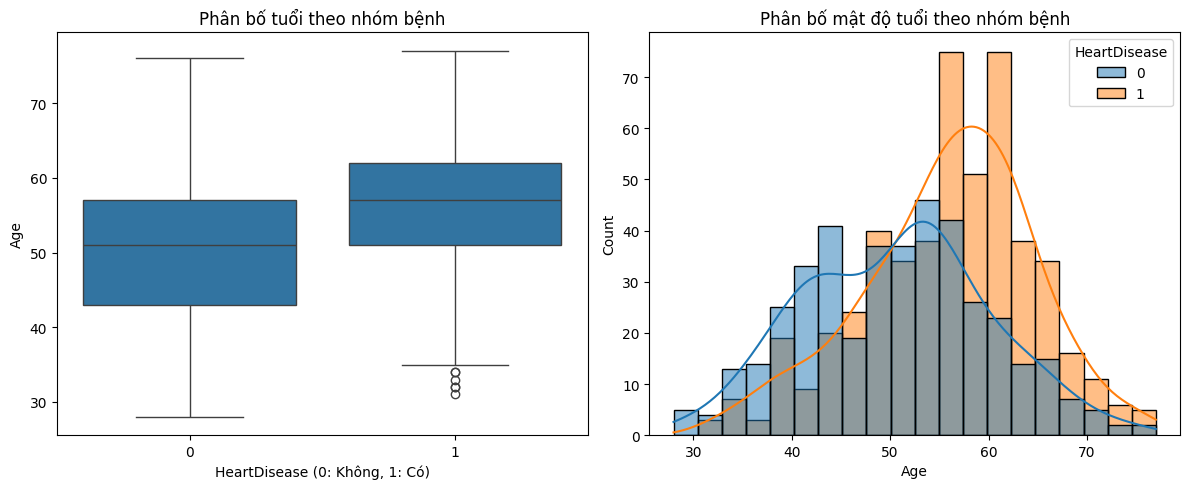

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Vẽ biểu đồ tuổi theo nhóm bệnh
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Biểu đồ 1: Boxplot tuổi
sns.boxplot(data=df, x='HeartDisease', y='Age', ax=axes[0])
axes[0].set_title('Phân bố tuổi theo nhóm bệnh')
axes[0].set_xlabel('HeartDisease (0: Không, 1: Có)')

# Biểu đồ 2: Histogram chồng
sns.histplot(data=df, x='Age', hue='HeartDisease', 
             kde=True, bins=20, alpha=0.5, ax=axes[1])
axes[1].set_title('Phân bố mật độ tuổi theo nhóm bệnh')

plt.tight_layout()
plt.show()
